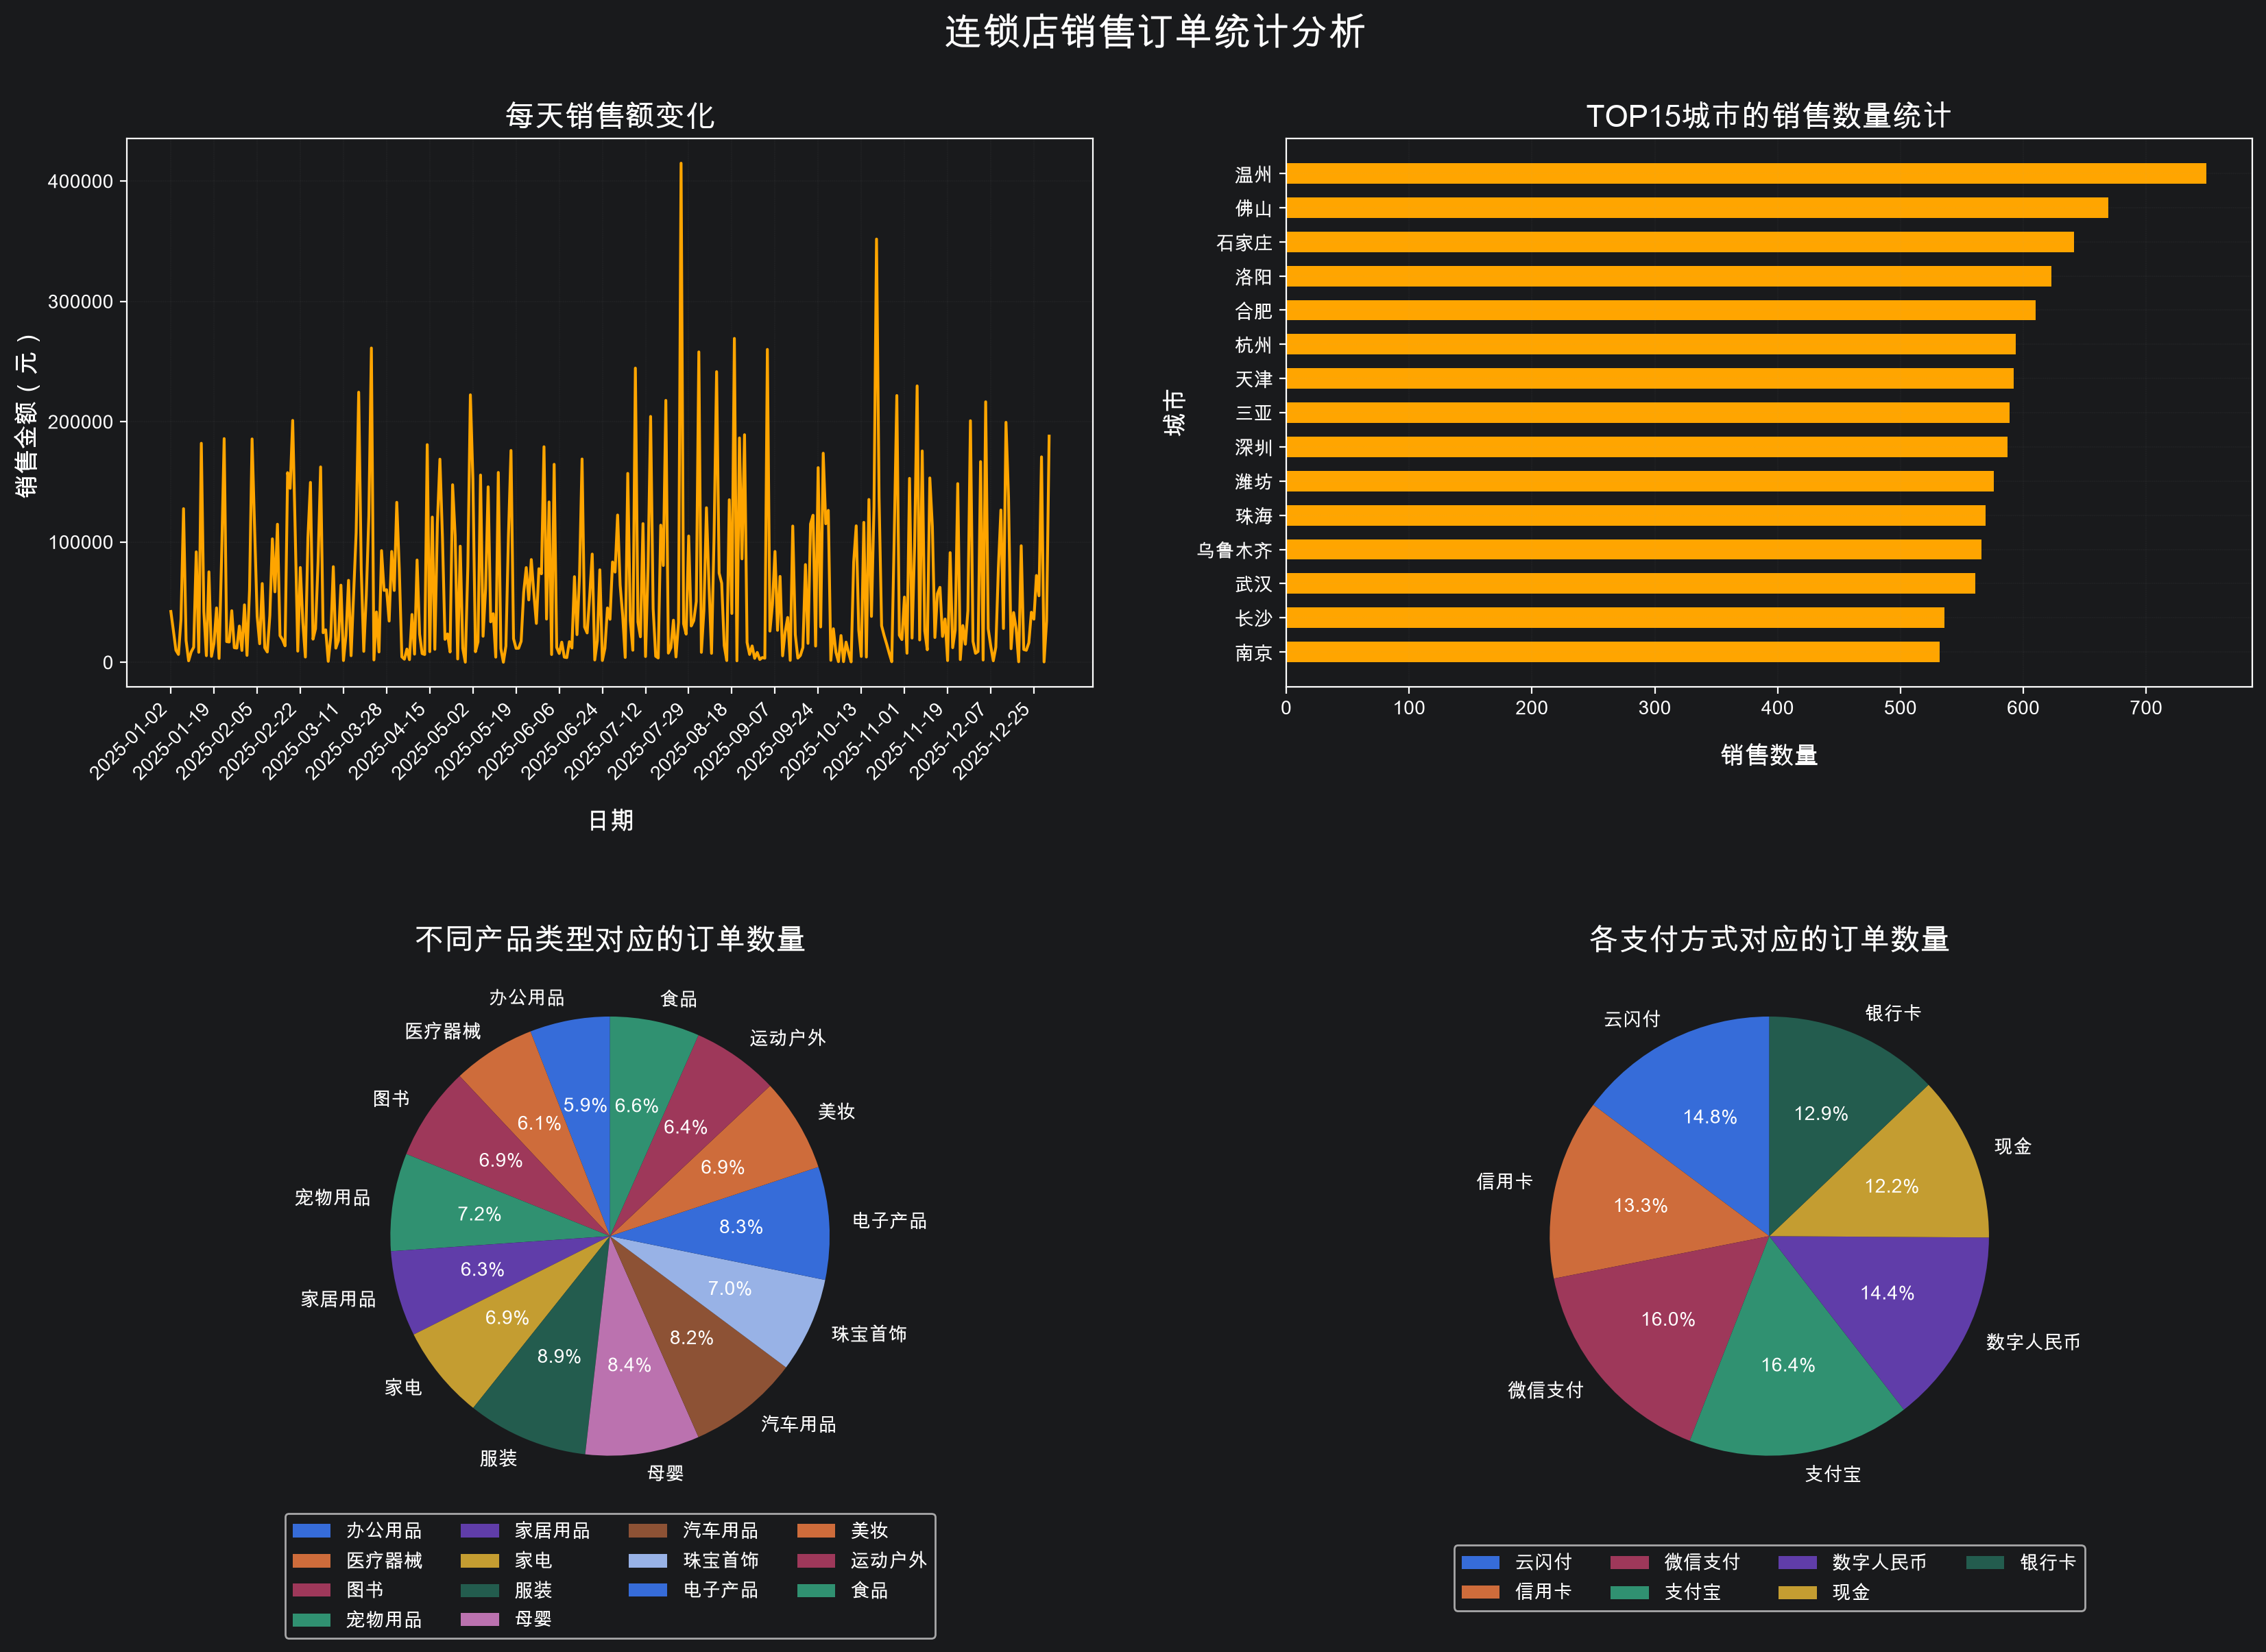

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

# 设置 Jupyter 内联输出为 Retina 高清格式
%config InlineBackend.figure_format = 'retina'

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
# 正常显示负号
plt.rcParams["axes.unicode_minus"] = False

# 加载数据
df = pd.read_csv('./data/new_sales.csv',
                 usecols=['订单号', '产品类别', '产品名称', '销售数量', '单价', '客户所在城市', '支付方式',
                          '订单日期'])

# 创建子图
figure, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 13), dpi=100)  # nrows: 行 ; ncols: 列 ; figsize: 控制画布大小
figure.suptitle('连锁店销售订单统计分析', fontsize=20, x=0.5, y=0.95)  # 设置整个画布的总标题，fontsize 为字体大小，x、y 控制标题位置
figure.subplots_adjust(hspace=0.5, wspace=0.2)  # 调整子图间距，hspace: 控制垂直间距，wspace: 控制水平间距

axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 缺失值、异常值处理
# df.isnull().sum() # 统计缺失值数量
df = df.ffill()  # 对缺失值用上一个非缺失值填充
# df[df['销售数量'] < 0]  # 查看销售数量 < 0 的数据
# df[df['单价'] < 0]  # 查看单价 < 0 的数据
df['单价'] = df['单价'].abs()  # 对单价存在的负数求取绝对值
df['订单日期'] = df['订单日期'].str.replace('/', '-')

# 需求1：统计每天销售额的变化 - 折线图
df['销售金额'] = df['单价'] * df['销售数量']
daily_sales = df.groupby('订单日期')['销售金额'].sum().sort_index()
x_date = daily_sales.index
y_sales = daily_sales.values

axes1.plot(range(len(x_date)), y_sales, color='orange', linewidth=1.5, linestyle='-')
axes1.set_title('每天销售额变化', fontsize=16)
axes1.set_xlabel('日期', fontsize=13, labelpad=13)
axes1.set_ylabel('销售金额（元）', fontsize=13)
# 设置x轴刻度，每隔一定天数显示一个日期
step = max(1, len(x_date) // 20)
axes1.set_xticks(range(0, len(x_date), step))
axes1.set_xticklabels([x_date[i] for i in range(0, len(x_date), step)], rotation=45, ha='right')
axes1.grid(True, linestyle='--', linewidth=0.1, alpha=0.3)

# 需求2：统计对比不同城市的累计销售数量 - 横向柱状图
# 只取前15名，数据较多避免拥挤
city_sales = df.groupby('客户所在城市')['销售数量'].sum().sort_values(ascending=False).head(15)
x_city = city_sales.index
y_city_count = city_sales.values

axes2.barh(x_city, y_city_count, color='orange', height=0.6)  # 柱状图
axes2.invert_yaxis()  # 让销量最高的排在最上面
axes2.set_title('TOP15城市的销售数量统计', fontsize=16)  # 设置子图标题
axes2.set_xlabel('销售数量', fontsize=13, labelpad=13)  # 设置X轴标签
axes2.set_ylabel('城市', fontsize=13)  # 设置Y轴标签
axes2.grid(linestyle='--', linewidth=0.1, alpha=0.3)  # 设置网格线

# 需求3：统计不同产品类型对应的订单比例 - 饼状图
category_count = df.groupby('产品类别').size()
x_category = category_count.index
y_category_count = category_count.values

axes3.pie(y_category_count, labels=x_category, autopct='%1.1f%%', startangle=90)
axes3.set_title('不同产品类型对应的订单数量', fontsize=16)
axes3.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.25))

# 需求4：同步不同支付方式对应的订单比例 - 饼状图
payment_count = df.groupby('支付方式').size()
x_payment = payment_count.index
y_payment_count = payment_count.values

axes4.pie(y_payment_count, labels=x_payment, autopct='%1.1f%%', startangle=90)
axes4.set_title('各支付方式对应的订单数量', fontsize=16)
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))

# 保存图片
plt.savefig('./data/连锁店销售订单统计分析.png', dpi=300)

plt.show()
